# 실습 2-1 : 다중선형회귀모형

#### **<실습 내용>**

1. 실습 데이터 탐색 및 전처리
- 구조적 정보 / 통계적 정보
- 상관행렬 히트맵 (다중공선성 확인)
- 입출력 변수 분할
- 학습/테스트 데이터 분할

2. 다중 선형 회귀
- 모델 학습 및 성능 평가
- 회귀 계수 확인

3. Ridge
- 규제 강도(alpha)에 따른 변화

4. Lasso
- 규제 강도(alpha)에 따른 변수 제거 효과

5. 모델 비교
- 회귀 계수 비교 시각화
- 다중공선성 해결 확인

## 분석 준비

### 주요 라이브러리 호출

In [2]:
import os
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

### 데이터 불러오기

In [3]:
Concrete_data = pd.read_csv(os.path.join(os.getcwd(), "dataset", "day2-1_data.csv"))

---

## 1) 데이터 탐색 및 전처리

### 1-1) 구조적 정보

In [4]:
# 앞부분 데이터 확인
Concrete_data.head()

,Cement,Blast_Furnace_Slag,Fly_Ash,Water,Superplasticizer,Coarse_Aggregate,Fine_Aggregate,Age,Concrete_compressive_strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [34]:
Concrete_data.columns

Index(['Cement', 'Blast_Furnace_Slag', 'Fly_Ash', 'Water', 'Superplasticizer',
       'Coarse_Aggregate', 'Fine_Aggregate', 'Age',
       'Concrete_compressive_strength'],
      dtype='object')

In [5]:
# 데이터 정보 확인
Concrete_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Cement                         1030 non-null   float64
 1   Blast_Furnace_Slag             1030 non-null   float64
 2   Fly_Ash                        1030 non-null   float64
 3   Water                          1030 non-null   float64
 4   Superplasticizer               1030 non-null   float64
 5   Coarse_Aggregate               1030 non-null   float64
 6   Fine_Aggregate                 1030 non-null   float64
 7   Age                            1030 non-null   int64  
 8   Concrete_compressive_strength  1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [6]:
# 데이터 크기 확인
print("데이터 크기 :", Concrete_data.shape)
print("변수명      :", list(Concrete_data.columns))

데이터 크기 : (1030, 9)
변수명      : ['Cement', 'Blast_Furnace_Slag', 'Fly_Ash', 'Water', 'Superplasticizer', 'Coarse_Aggregate', 'Fine_Aggregate', 'Age', 'Concrete_compressive_strength']


- 콘크리트의 배합 재료(시멘트, 슬래그, 플라이애시, 물, 혼화제, 굵은/잔골재)와 양생 기간(Age)을 입력으로, 콘크리트 압축강도(Concrete_compressive_strength)를 예측하는 회귀 데이터

### 1-2) 통계적 정보

In [7]:
# 요약 통계량 확인
Concrete_data.describe()

,Cement,Blast_Furnace_Slag,Fly_Ash,Water,Superplasticizer,Coarse_Aggregate,Fine_Aggregate,Age,Concrete_compressive_strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


### 1-3) 시각적 탐색

#### 1-3-1) 히스토그램

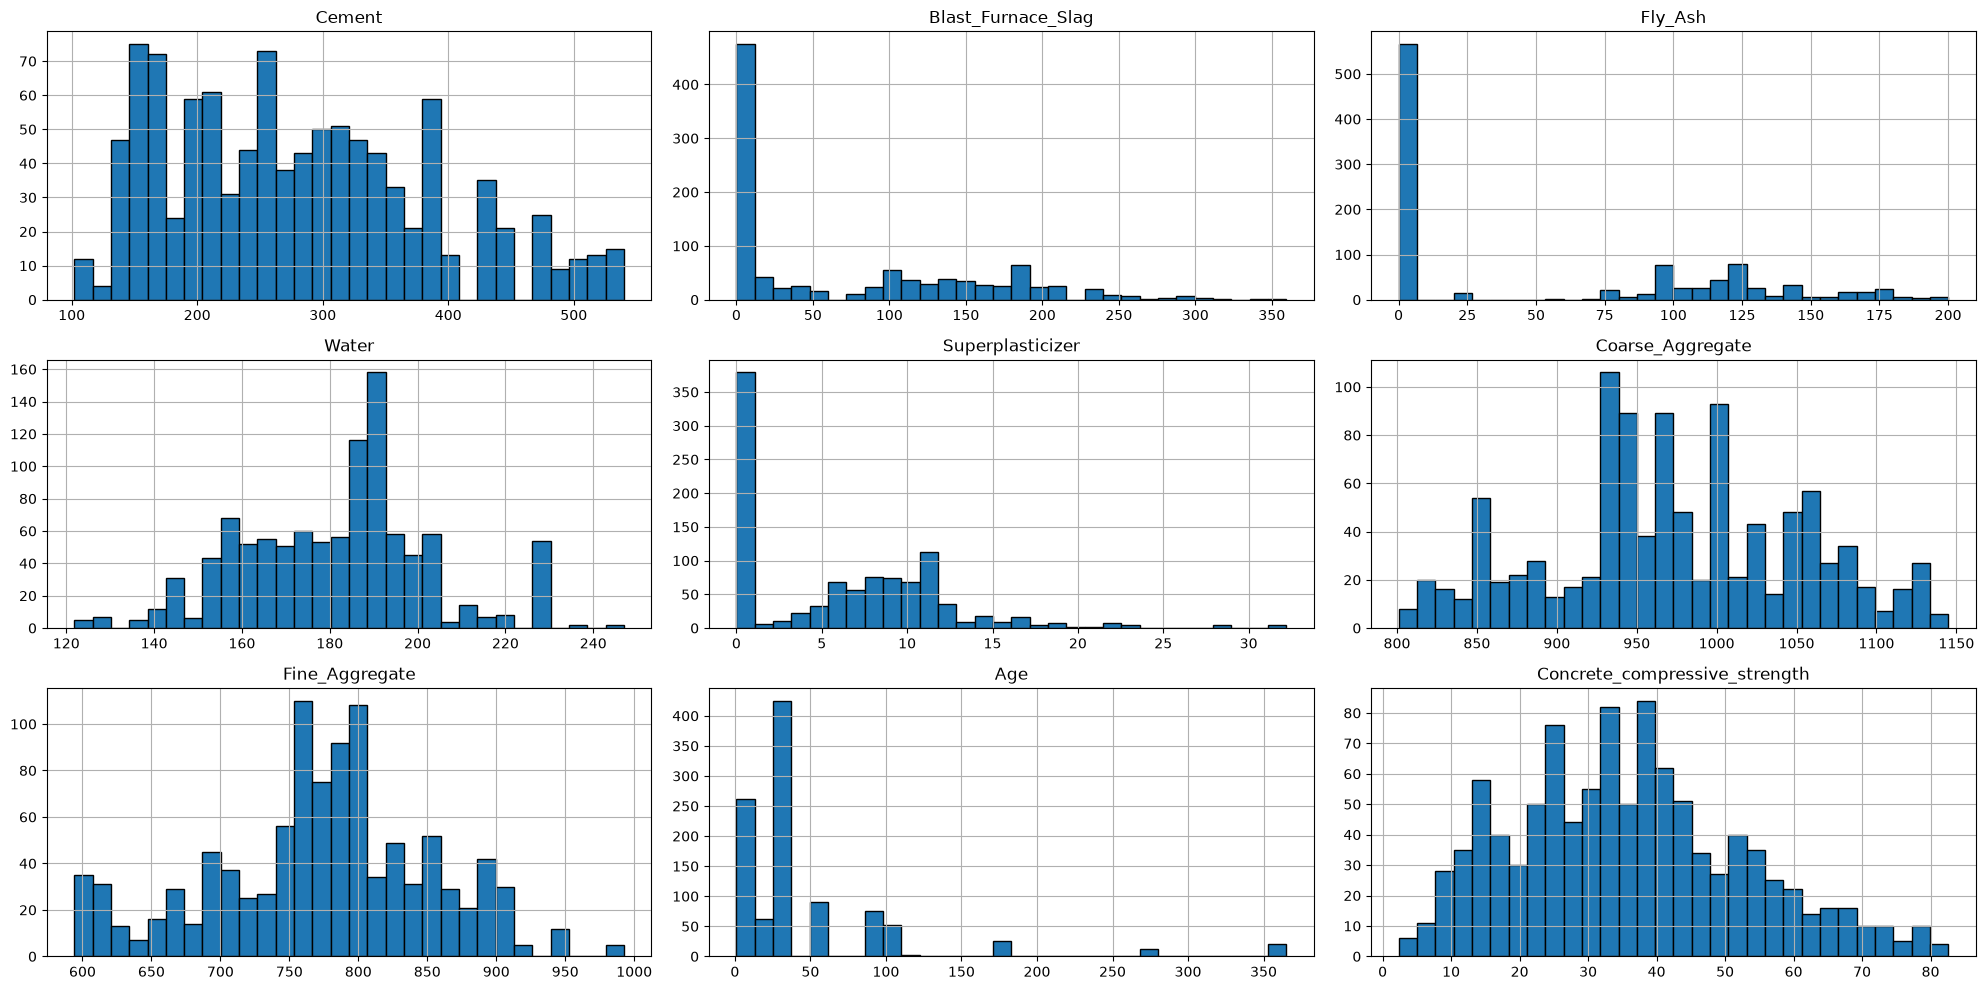

In [8]:
Concrete_data.hist(figsize=(20, 10), bins=30, edgecolor="black")
plt.tight_layout()
plt.show()

#### 1-3-2) 상관행렬 히트맵

> **다중공선성(Multicollinearity)** 은 입력변수들 사이에 강한 상관관계가 존재하는 현상임
> - 다중공선성이 존재하면 **회귀 계수의 추정이 불안정**해지고, 학습 데이터에 따라 계수의 변동성이 커짐
>   - 예: 집 면적과 방 개수처럼 비슷한 정보를 가진 변수가 함께 있으면, 모델이 각 변수의 영향을 구분하기 어려워 데이터가 조금만 달라져도 회귀계수가 크게 변할 수 있음
> - 상관행렬 히트맵을 통해 변수 간 상관관계를 시각적으로 확인할 수 있음

In [9]:
# 변수 간 상관계수 확인
Concrete_data.corr(numeric_only=True)

,Cement,Blast_Furnace_Slag,Fly_Ash,Water,Superplasticizer,Coarse_Aggregate,Fine_Aggregate,Age,Concrete_compressive_strength
Cement,1.000000,-0.275216,-0.397467,-0.081587,0.092386,-0.109349,-0.222718,0.081946,0.497832
Blast_Furnace_Slag,-0.275216,1.000000,-0.323580,0.107252,0.043270,-0.283999,-0.281603,-0.044246,0.134829
Fly_Ash,-0.397467,-0.323580,1.000000,-0.256984,0.377503,-0.009961,0.079108,-0.154371,-0.105755
Water,-0.081587,0.107252,-0.256984,1.000000,-0.657533,-0.182294,-0.450661,0.277618,-0.289633
Superplasticizer,0.092386,0.043270,0.377503,-0.657533,1.000000,-0.265999,0.222691,-0.192700,0.366079
Coarse_Aggregate,-0.109349,-0.283999,-0.009961,-0.182294,-0.265999,1.000000,-0.178481,-0.003016,-0.164935
Fine_Aggregate,-0.222718,-0.281603,0.079108,-0.450661,0.222691,-0.178481,1.000000,-0.156095,-0.167241
Age,0.081946,-0.044246,-0.154371,0.277618,-0.192700,-0.003016,-0.156095,1.000000,0.328873
Concrete_compressive_strength,0.497832,0.134829,-0.105755,-0.289633,0.366079,-0.164935,-0.167241,0.328873,1.000000


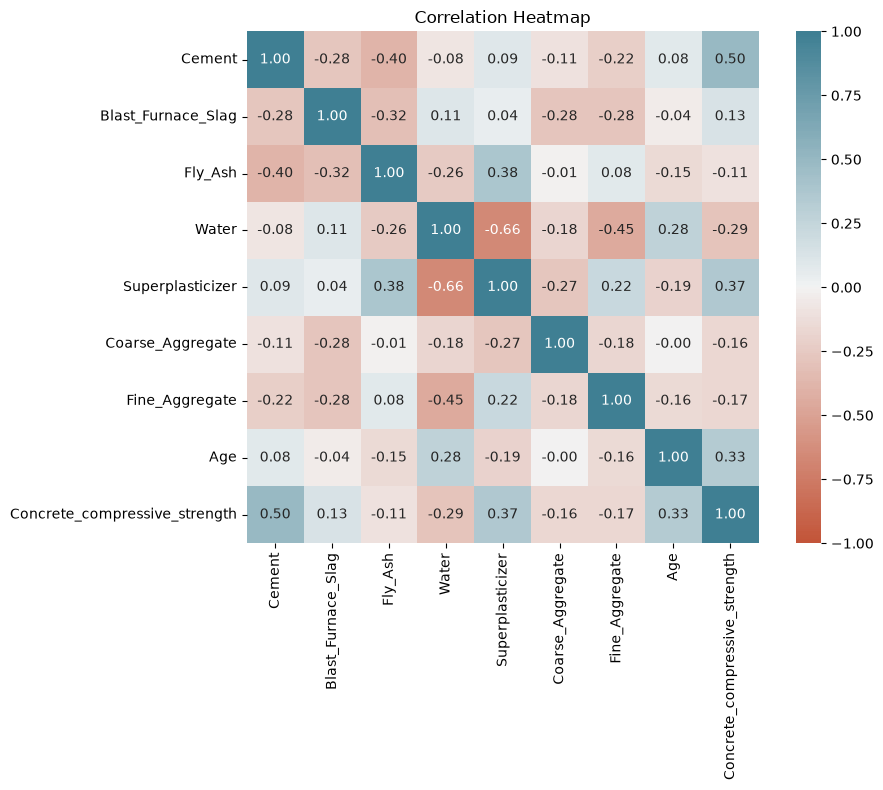

In [10]:
# 상관행렬 히트맵 시각화
plt.figure(figsize=(10, 8))

sns.heatmap(
    Concrete_data.corr(numeric_only=True),
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    annot=True,
    fmt=".2f",
    square=True
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

- WATER: 콘크리트를 만들 때 사용하는 물의 양
- SUPERplasticizer: 물을 많이 넣지 않아도 콘크리트가 잘 섞이고 잘 흐르도록 해주는 화학 첨가제(고성능 감수제)
- **음의 상관관계 이유:** SUPERplasticizer를 많이 사용하면 물(WATER)을 적게 넣어도 되기 때문에 일반적으로 한쪽이 증가하면 다른 한쪽은 감소하는 경향을 보임

### 1-4) 결측치 확인

In [11]:
# 변수별 결측치 개수 확인
Concrete_data.isnull().sum()

Cement                           0
Blast_Furnace_Slag               0
Fly_Ash                          0
Water                            0
Superplasticizer                 0
Coarse_Aggregate                 0
Fine_Aggregate                   0
Age                              0
Concrete_compressive_strength    0
dtype: int64

### 1-5) 입출력 변수 분할

In [12]:
Y = Concrete_data["Concrete_compressive_strength"]
X = Concrete_data.drop(["Concrete_compressive_strength"], axis=1)

print("입력변수 크기 :", X.shape)
print("출력변수 크기 :", Y.shape)

입력변수 크기 : (1030, 8)
출력변수 크기 : (1030,)


### 1-6) 학습/테스트 데이터 분할

In [13]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=0)

print("전체 데이터 크기   :", X.shape, Y.shape)
print("학습 데이터 크기   :", X_train.shape, Y_train.shape)
print("테스트 데이터 크기 :", X_test.shape, Y_test.shape)

전체 데이터 크기   : (1030, 8) (1030,)
학습 데이터 크기   : (721, 8) (721,)
테스트 데이터 크기 : (309, 8) (309,)


---

## 2) 다중 선형 회귀

> **다중선형회귀**는 여러 입력변수를 동시에 고려하여 출력변수를 예측하는 모델임
> - 회귀식: $\hat{Y} = \hat{\beta}_0 + \hat{\beta}_1 X_1 + \hat{\beta}_2 X_2 + \cdots + \hat{\beta}_p X_p$
> - **최소자승법(OLS)** 으로 잔차의 제곱합(SSE)을 최소화하는 회귀 계수를 추정함
> - 회귀 계수 $\hat{\beta}_i$는 다른 변수가 고정된 상태에서 $X_i$가 1단위 증가할 때 $Y$의 변화량을 의미함

In [14]:
# 회귀 모형 성능 지표 산출 함수
def get_regscore(true, pred):
    print("MSE       : %.3f" % (mean_squared_error(true, pred)))
    print("RMSE      : %.3f" % (np.sqrt(mean_squared_error(true, pred))))
    print("MAE       : %.3f" % (mean_absolute_error(true, pred)))
    print("R-squared : %.3f" % (r2_score(true, pred)))

### 2-1) 모델 학습

In [15]:
LR_model = LinearRegression()
LR_model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[0.12,0.11,0.09,...,0.02,0.02,0.11]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['Cement','Blast_Furnace_Slag','Fly_Ash',...,'Coarse_Aggregate', 'Fine_Aggregate','Age']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-36.63
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


### 2-2) 회귀 계수 확인

> 회귀 계수의 부호와 크기를 통해 각 입력변수가 출력변수에 미치는 **영향의 방향과 크기**를 파악할 수 있음

In [16]:
print("절편 (beta0) :", LR_model.intercept_)
print("회귀 계수    :", LR_model.coef_)

절편 (beta0) : -36.62862724393965
회귀 계수    : [ 0.1213222   0.10790307  0.09202681 -0.13251221  0.35446729  0.02377324
  0.0242502   0.11101382]


In [17]:
Coef_LR = pd.DataFrame({"Variable": X_train.columns, "Coefficient": LR_model.coef_})
Coef_LR

,Variable,Coefficient
0,Cement,0.121322
1,Blast_Furnace_Slag,0.107903
2,Fly_Ash,0.092027
3,Water,-0.132512
4,Superplasticizer,0.354467
5,Coarse_Aggregate,0.023773
6,Fine_Aggregate,0.024250
7,Age,0.111014


### 2-3) 성능 평가

> **R-squared (결정계수)** 는 모델이 데이터를 얼마나 잘 설명하는지를 나타내는 지표임
> - $R^2 = 1 - \frac{SSE}{SST}$ 이며, 1에 가까울수록 모델의 설명력이 높음
> - 학습 데이터에서 $R^2$의 최솟값은 0이지만, 테스트 데이터에서는 **음수**가 나올 수 있음

In [18]:
Y_pred_LR = LR_model.predict(X_test)
get_regscore(Y_test, Y_pred_LR)

MSE       : 93.619
RMSE      : 9.676
MAE       : 7.776
R-squared : 0.635


### 2-4) 예측 시각화

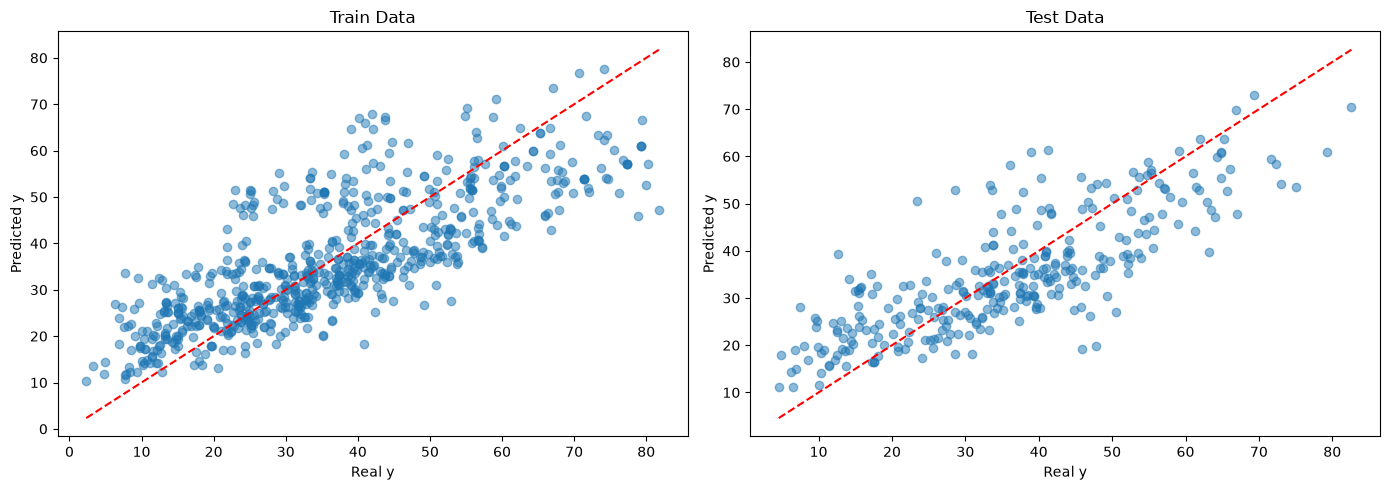

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(Y_train, LR_model.predict(X_train), alpha=0.5)
axes[0].plot([Y_train.min(), Y_train.max()], [Y_train.min(), Y_train.max()], "r--")
axes[0].set_xlabel("Real y")
axes[0].set_ylabel("Predicted y")
axes[0].set_title("Train Data")

axes[1].scatter(Y_test, Y_pred_LR, alpha=0.5)
axes[1].plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], "r--")
axes[1].set_xlabel("Real y")
axes[1].set_ylabel("Predicted y")
axes[1].set_title("Test Data")

plt.tight_layout()
plt.show()

---

## 3) Ridge

> **Ridge 회귀**는 OLS의 손실 함수에 **회귀 계수의 제곱합(L2 규제)** 을 추가하여 계수의 크기를 줄임
>
> $$Minimize \sum(y_i - \hat{y}_i)^2 + \alpha \sum \hat{\beta}_j^2$$
>
> - 모든 변수를 유지하되, 계수의 크기를 **전반적으로 축소**함
> - alpha(λ)가 클수록 규제가 강해져 계수가 0에 가까워짐
> - 입력변수들이 비슷한 수준으로 출력변수에 영향을 미치는 경우에 적합한 모델임

### 3-1) 모델 학습 및 성능 평가 (alpha=0.1)

In [38]:
Ridge_model_1 = Ridge(alpha=0.1)
Ridge_model_1.fit(X_train, Y_train)
Ridge_pred_1 = Ridge_model_1.predict(X_test)
get_regscore(Y_test, Ridge_pred_1)

MSE       : 93.619
RMSE      : 9.676
MAE       : 7.776
R-squared : 0.635


### 3-2) 회귀 계수 확인

In [37]:
import numpy as np

for i in np.arange(1, 10, 1):
  Ridge_model=Ridge(alpha=i)
  Ridge_model.fit(X_train,Y_train)
  Ridge_pred=Ridge_model.predict(X_test)
  print(f"----- Result(alpha={i}) -----")
  get_regscore(Y_test,Ridge_pred)

----- Result(alpha=1) -----
MSE       : 93.619
RMSE      : 9.676
MAE       : 7.776
R-squared : 0.635
----- Result(alpha=2) -----
MSE       : 93.618
RMSE      : 9.676
MAE       : 7.776
R-squared : 0.635
----- Result(alpha=3) -----
MSE       : 93.618
RMSE      : 9.676
MAE       : 7.776
R-squared : 0.635
----- Result(alpha=4) -----
MSE       : 93.618
RMSE      : 9.676
MAE       : 7.776
R-squared : 0.635
----- Result(alpha=5) -----
MSE       : 93.618
RMSE      : 9.676
MAE       : 7.776
R-squared : 0.635
----- Result(alpha=6) -----
MSE       : 93.618
RMSE      : 9.676
MAE       : 7.776
R-squared : 0.635
----- Result(alpha=7) -----
MSE       : 93.617
RMSE      : 9.676
MAE       : 7.776
R-squared : 0.635
----- Result(alpha=8) -----
MSE       : 93.617
RMSE      : 9.676
MAE       : 7.776
R-squared : 0.635
----- Result(alpha=9) -----
MSE       : 93.617
RMSE      : 9.676
MAE       : 7.776
R-squared : 0.635


In [39]:
Coef_Ridge_1 = pd.DataFrame({"Variable": X_train.columns, "Coefficient": Ridge_model_1.coef_})
Coef_Ridge_1

,Variable,Coefficient
0,Cement,0.121322
1,Blast_Furnace_Slag,0.107903
2,Fly_Ash,0.092027
3,Water,-0.132513
4,Superplasticizer,0.354464
5,Coarse_Aggregate,0.023773
6,Fine_Aggregate,0.024250
7,Age,0.111014


### 3-3) alpha 값 변경 (alpha=10)

In [22]:
Ridge_model_2 = Ridge(alpha=10)
Ridge_model_2.fit(X_train, Y_train)
Ridge_pred_2 = Ridge_model_2.predict(X_test)
get_regscore(Y_test, Ridge_pred_2)

MSE       : 93.617
RMSE      : 9.676
MAE       : 7.776
R-squared : 0.635


In [23]:
Coef_Ridge_2 = pd.DataFrame({"Variable": X_train.columns, "Coefficient": Ridge_model_2.coef_})
Coef_Ridge_2

,Variable,Coefficient
0,Cement,0.121322
1,Blast_Furnace_Slag,0.107902
2,Fly_Ash,0.092032
3,Water,-0.132588
4,Superplasticizer,0.354104
5,Coarse_Aggregate,0.023761
6,Fine_Aggregate,0.024244
7,Age,0.111014


---

## 4) Lasso

> **Lasso 회귀**는 OLS의 손실 함수에 **회귀 계수의 절대값 합(L1 규제)** 을 추가함
>
> $$Minimize \sum(y_i - \hat{y}_i)^2 + \alpha \sum |\hat{\beta}_j|$$
>
> - Ridge와 달리 불필요한 변수의 계수를 **완전히 0으로** 만들어 변수를 제거함
> - alpha(λ)가 클수록 더 많은 변수가 제거됨
> - 출력변수에 미치는 입력변수의 영향력 편차가 큰 경우에 적합한 모델임

### 4-1) 모델 학습 및 성능 평가 (alpha=0.1)

In [41]:
Lasso_model_1 = Lasso(alpha=0.1)
Lasso_model_1.fit(X_train, Y_train)
Lasso_pred_1 = Lasso_model_1.predict(X_test)
get_regscore(Y_test, Lasso_pred_1)

MSE       : 93.577
RMSE      : 9.674
MAE       : 7.773
R-squared : 0.635


### 4-2) 회귀 계수 확인

In [42]:
Coef_Lasso_1 = pd.DataFrame({"Variable": X_train.columns, "Coefficient": Lasso_model_1.coef_})
Coef_Lasso_1

,Variable,Coefficient
0,Cement,0.121177
1,Blast_Furnace_Slag,0.107709
2,Fly_Ash,0.091909
3,Water,-0.134217
4,Superplasticizer,0.347872
5,Coarse_Aggregate,0.023401
6,Fine_Aggregate,0.023971
7,Age,0.110966


In [43]:
# 계수가 0인 변수 확인 (제거된 변수)
Coef_Lasso_1.loc[Coef_Lasso_1["Coefficient"] == 0]

,Variable,Coefficient


### 4-3) alpha 값 변경 (alpha=10)

In [27]:
Lasso_model_2 = Lasso(alpha=10)
Lasso_model_2.fit(X_train, Y_train)
Lasso_pred_2 = Lasso_model_2.predict(X_test)
get_regscore(Y_test, Lasso_pred_2)

MSE       : 93.174
RMSE      : 9.653
MAE       : 7.708
R-squared : 0.637


### 4-4) 변수 제거 효과 확인

> alpha 값이 커질수록 Lasso는 더 많은 변수의 계수를 0으로 만들어 **자동으로 변수 선택**을 수행합니다.

In [28]:
Coef_Lasso_2 = pd.DataFrame({"Variable": X_train.columns, "Coefficient": Lasso_model_2.coef_})
Coef_Lasso_2

,Variable,Coefficient
0,Cement,0.109155
1,Blast_Furnace_Slag,0.091635
2,Fly_Ash,0.078794
3,Water,-0.226301
4,Superplasticizer,0.000000
5,Coarse_Aggregate,0.000000
6,Fine_Aggregate,0.004620
7,Age,0.105939


In [29]:
# alpha=10에서 제거된 변수
print("제거된 변수:")
print(Coef_Lasso_2.loc[Coef_Lasso_2["Coefficient"] == 0])
print()
print("선택된 변수:")
print(Coef_Lasso_2.loc[Coef_Lasso_2["Coefficient"] != 0])

제거된 변수:
           Variable  Coefficient
4  Superplasticizer          0.0
5  Coarse_Aggregate          0.0

선택된 변수:
             Variable  Coefficient
0              Cement     0.109155
1  Blast_Furnace_Slag     0.091635
2             Fly_Ash     0.078794
3               Water    -0.226301
6      Fine_Aggregate     0.004620
7                 Age     0.105939


---

## 5) 모델 비교

### 5-1) 회귀 계수 비교 시각화

> Ridge는 계수를 **0에 가깝게** 축소하고, Lasso는 계수를 **완전히 0으로** 만듦

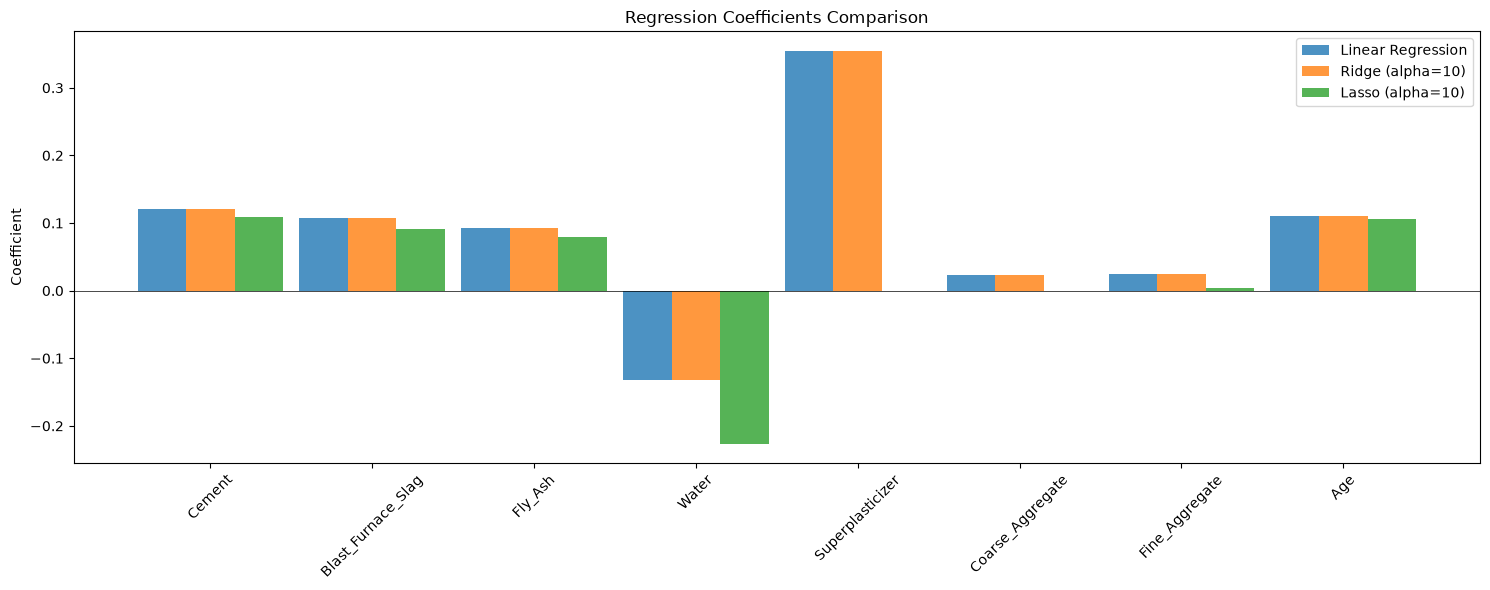

In [30]:
plt.figure(figsize=(15, 6))

x_pos = np.arange(len(X_train.columns))
width = 0.3

plt.bar(x_pos - width, LR_model.coef_, width, label="Linear Regression", alpha=0.8)
plt.bar(x_pos, Ridge_model_2.coef_, width, label="Ridge (alpha=10)", alpha=0.8)
plt.bar(x_pos + width, Lasso_model_2.coef_, width, label="Lasso (alpha=10)", alpha=0.8)

plt.xticks(x_pos, X_train.columns, rotation=45)
plt.ylabel("Coefficient")
plt.title("Regression Coefficients Comparison")
plt.legend()
plt.axhline(y=0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

### 5-2) 다중공선성 해결 확인

> Lasso가 제거한 변수를 제외한 후, 남은 변수들의 상관행렬을 비교하여 다중공선성이 완화되었는지 확인함

In [31]:
# Lasso(alpha=10)에서 선택된 변수만 추출
selected_vars = Coef_Lasso_2.loc[Coef_Lasso_2["Coefficient"] != 0, "Variable"].tolist()
print("Lasso가 선택한 변수:", selected_vars)

Lasso가 선택한 변수: ['Cement', 'Blast_Furnace_Slag', 'Fly_Ash', 'Water', 'Fine_Aggregate', 'Age']


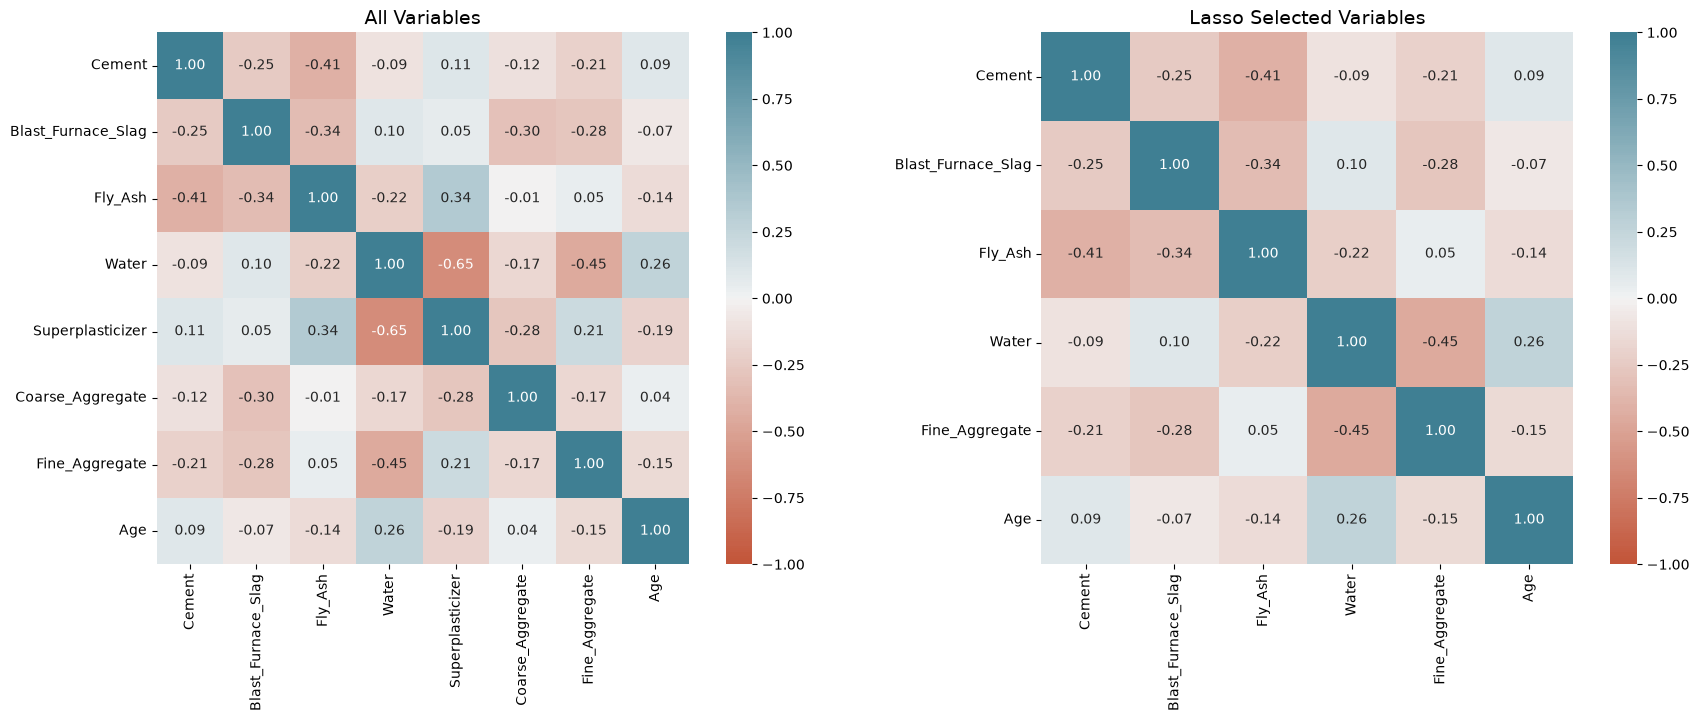

In [32]:
# 전체 변수 vs Lasso 선택 변수 상관행렬 비교
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(
    X_train.corr(), vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    annot=True, fmt=".2f", square=True, ax=axes[0]
)
axes[0].set_title("All Variables", fontsize=14)

sns.heatmap(
    X_train[selected_vars].corr(), vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    annot=True, fmt=".2f", square=True, ax=axes[1]
)
axes[1].set_title("Lasso Selected Variables", fontsize=14)

plt.tight_layout()
plt.show()

### 5-3) 성능 비교 요약

In [33]:
# 모델별 성능 비교표
results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge (alpha=0.1)", "Ridge (alpha=10)",
              "Lasso (alpha=0.1)", "Lasso (alpha=10)"],
    "RMSE": [
        np.sqrt(mean_squared_error(Y_test, Y_pred_LR)),
        np.sqrt(mean_squared_error(Y_test, Ridge_pred_1)),
        np.sqrt(mean_squared_error(Y_test, Ridge_pred_2)),
        np.sqrt(mean_squared_error(Y_test, Lasso_pred_1)),
        np.sqrt(mean_squared_error(Y_test, Lasso_pred_2)),
    ],
    "R-squared": [
        r2_score(Y_test, Y_pred_LR),
        r2_score(Y_test, Ridge_pred_1),
        r2_score(Y_test, Ridge_pred_2),
        r2_score(Y_test, Lasso_pred_1),
        r2_score(Y_test, Lasso_pred_2),
    ]
})

results["RMSE"] = results["RMSE"].round(3)
results["R-squared"] = results["R-squared"].round(3)
results

,Model,RMSE,R-squared
0,Linear Regression,9.676,0.635
1,Ridge (alpha=0.1),9.676,0.635
2,Ridge (alpha=10),9.676,0.635
3,Lasso (alpha=0.1),9.674,0.635
4,Lasso (alpha=10),9.653,0.637


---

## 6) Vibe Coding 실습

### 6-1) 데이터 탐색 심화

**[과제 1]** 지수는 콘크리트 데이터셋을 처음 접했을 때, 각 변수를 개별적으로 봤을 때(단일 변수 관점), 두 변수씩 짝지어 봤을 때(두 변수 간 관점), 그리고 여러 변수를 한꺼번에 놓고 봤을 때(다변수 관점) 각각 어떤 특성과 관계가 드러나는지 단계적으로 파악하고 싶습니다. 특히 각 설명변수가 압축강도(Y)와 어떤 관계를 갖는지가 가장 궁금합니다. 이 세 가지 관점 각각에 적용할 수 있는 탐색적 데이터 분석(EDA) 방법들을 AI와 상의해서 나열하고, 직접 코드로 탐색해 본 뒤 그 결과가 의미하는 바를 분석해 보세요.

### 6-2) 전처리 심화

**[과제 2]** 지수는 데이터셋을 분석하던 중 콘크리트 강도가 단일 변수보다 변수 간 비율이나 조합에 더 큰 영향을 받을 수 있다고 판단했습니다. AI와 상의하여 새로운 파생변수를 만들고, 해당 변수를 추가했을 때 선형 회귀 성능이 개선되는지 확인해 보세요.

### 6-3) Ridge/Lasso 모델링 및 고도화 심화

**[과제 3]** 지수는 Ridge와 Lasso의 alpha를 0.1, 10 두 값만 비교했는데, 최적의 alpha가 그 사이 어딘가에 있을 수도 있다고 생각합니다. 직접 여러 alpha 값을 하나씩 대입해보는 것 말고 더 체계적으로 최적 alpha를 찾는 방법을 AI와 상의해서 정하고, 실제로 최적 alpha를 탐색해 보세요.

**[과제 4]** 지수는 Ridge(L2)와 Lasso(L1)의 장점을 함께 활용할 수 있는 방법이 없는지 궁금해졌습니다. AI와 함께 적절한 모델을 찾아보고, 해당 모델의 특징과 활용 상황을 정리한 뒤 직접 적용하여 Ridge, Lasso와 성능 및 회귀 계수를 비교해 보세요.

**[과제 5]** 지수는 분석 과정에서 양생 기간(Age)이 길어질수록 강도가 증가하지만, 그 증가 폭은 점점 줄어드는 비선형 관계일 수 있다는 생각이 들었습니다. 선형 회귀 모델이 이런 비선형 관계를 잘 잡아내지 못할 수 있다는 점을 AI와 논의하고, 비선형성을 반영할 수 있는 방법을 적용해 성능이 개선되는지 확인해 보세요.